# Прогнозирование оттока клиентов телеком-провайдера
### Кому и когда звонить из retention-команды

**Автор:** Сюльжин Савелий

**Бизнес-задача.** Удержать существующего клиента дешевле, чем привлечь нового, но звонить всем подряд — дорого и раздражает лояльных клиентов. Задача — понять, какие факторы связаны с оттоком, оценить, как быстро компания теряет клиентов во времени, и построить модель, которая заранее выделяет клиентов с высоким риском ухода для точечной retention-кампании.

**Данные.** Telco Customer Churn — 7043 клиента телеком-провайдера, срез на момент выгрузки (без истории по датам), для каждого — тип контракта, услуги, платежи и признак ухода (`Churn`).


## 1. Загрузка и предобработка

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve, classification_report)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Размер:", df.shape)
df.head()


Размер: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


`TotalCharges` подгружен как текст — переводим в число и разбираемся, откуда берутся пропуски, вместо того чтобы сразу заполнять их «на автомате».

In [2]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Пропусков в TotalCharges после преобразования:", df["TotalCharges"].isnull().sum())
print(df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]])


Пропусков в TotalCharges после преобразования: 11
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


**Все 11 пропусков — клиенты с `tenure = 0`**, то есть подключились совсем недавно и ещё не получили ни одного счёта. Заполнять такие пропуски медианой (~$1400) было бы ошибкой: это придумало бы клиенту историю платежей, которой физически не было. Корректно — заполнить нулём: счетов пока не выставлялось.

In [3]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Пропуски по всему датасету:", df.isnull().sum().sum())
print(f"Доля оттока: {df['Churn'].mean():.1%}")


Пропуски по всему датасету: 0
Доля оттока: 26.5%


**Важно для дальнейшего:** классы разбалансированы — оттёкших клиентов 26.5%, остальных 73.5%. Это значит, что модель, которая всегда предсказывает «не уйдёт», уже будет иметь accuracy 73.5% — простое accuracy здесь плохо показывает качество, к этому вернёмся в разделе про модель.

## 2. Кто уходит: разведочный анализ и статистическая значимость

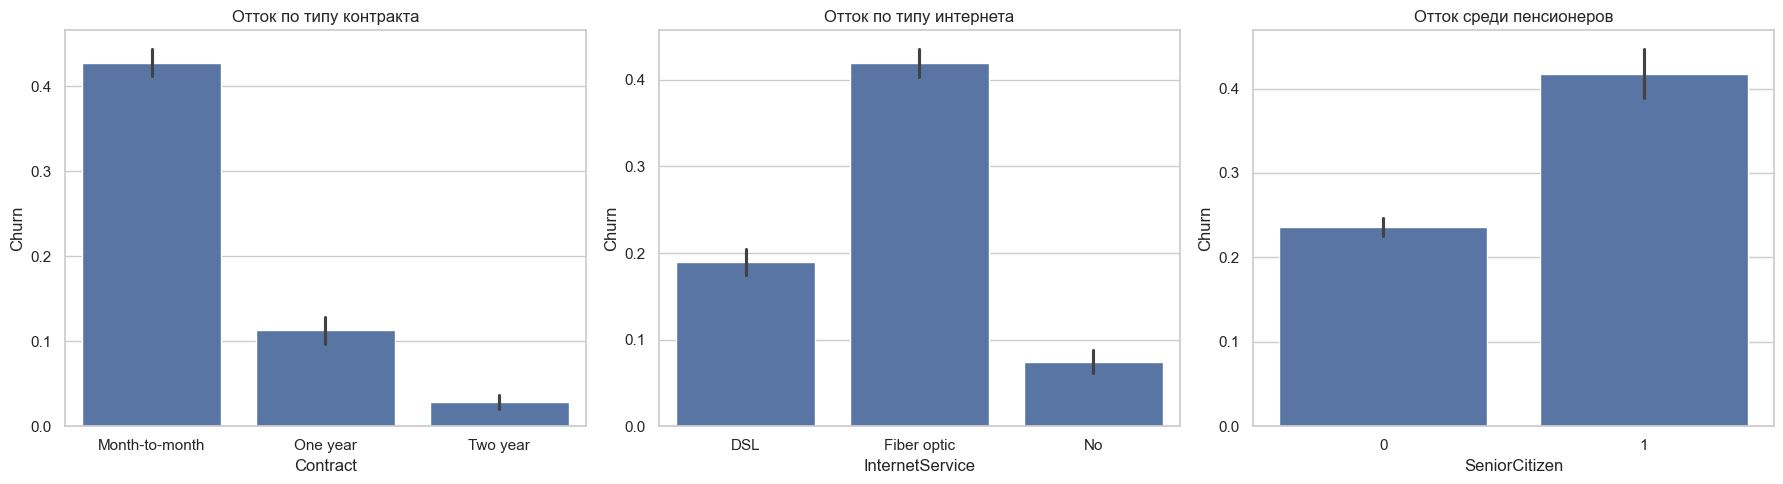

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x="Contract", y="Churn", data=df, ax=axes[0])
axes[0].set_title("Отток по типу контракта")
sns.barplot(x="InternetService", y="Churn", data=df, ax=axes[1])
axes[1].set_title("Отток по типу интернета")
sns.barplot(x="SeniorCitizen", y="Churn", data=df, ax=axes[2])
axes[2].set_title("Отток среди пенсионеров")
plt.tight_layout()
plt.show()


На глаз разница видна, но чтобы не принимать желаемое за действительное, проверяем каждую связь тестом хи-квадрат (обе переменные категориальные — доля оттока внутри группы vs между группами).

In [5]:
for col in ["Contract", "InternetService", "SeniorCitizen"]:
    table = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, expected = stats.chi2_contingency(table)
    print(f"{col}: chi2 = {chi2:.1f}, p-value = {p:.2e}")


Contract: chi2 = 1184.6, p-value = 5.86e-258
InternetService: chi2 = 732.3, p-value = 9.57e-160
SeniorCitizen: chi2 = 159.4, p-value = 1.51e-36


**Вывод:** все три связи статистически значимы (p ≪ 0.001) — это не случайные колебания выборки. `Contract` и `InternetService` дают самый большой разброс: отток на месячных контрактах (42.7%) в 15 раз выше, чем на двухлетних (2.8%); отток на Fiber optic (41.9%) более чем вдвое выше, чем на DSL (19.0%).

## 3. Как долго держится клиент: кривая удержания (Kaplan-Meier)

В данных нет дат подключения — только `tenure` (сколько месяцев клиент уже с компанией на момент среза) и финальный статус `Churn`. Это классическая структура данных для анализа выживаемости: для ушедших клиентов `tenure` — это полный срок жизни до ухода, для активных — срок жизни **на данный момент**, который ещё не завершён (censored-наблюдение, "право-цензурированные" данные).

Обычный «когортный» анализ (группировка по фиксированным интервалам tenure и подсчёт retention) здесь методологически некорректен — нет повторных наблюдений во времени за одной и той же группой клиентов, есть только один срез. Корректный инструмент — оценка Каплана-Мейера: доля клиентов, доживших до месяца *t*, без потери информации о цензурированных (ещё активных) наблюдениях.

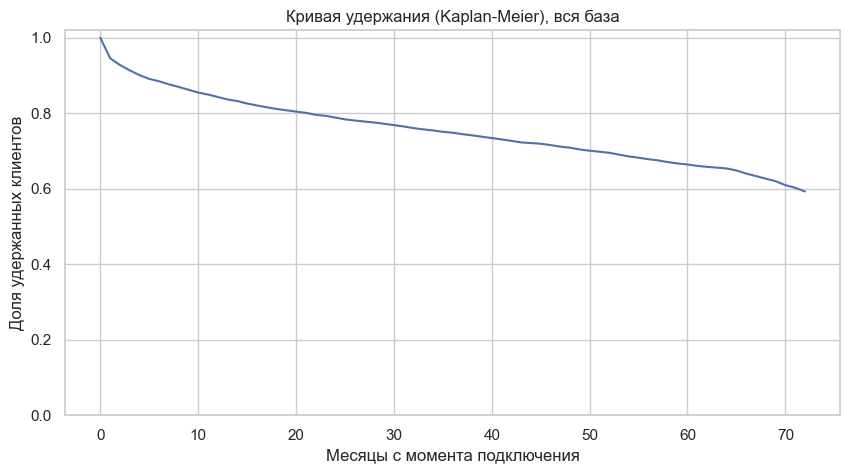

In [6]:
def kaplan_meier(data, duration_col="tenure", event_col="Churn"):
    times = sorted(data[duration_col].unique())
    survival = 1.0
    curve = []
    for t in times:
        at_risk = (data[duration_col] >= t).sum()
        events = ((data[duration_col] == t) & (data[event_col] == 1)).sum()
        if at_risk > 0:
            survival *= (1 - events / at_risk)
        curve.append((t, survival))
    return pd.DataFrame(curve, columns=["tenure", "survival"])

km_overall = kaplan_meier(df)

plt.figure(figsize=(10, 5))
plt.plot(km_overall["tenure"], km_overall["survival"])
plt.xlabel("Месяцы с момента подключения")
plt.ylabel("Доля удержанных клиентов")
plt.title("Кривая удержания (Kaplan-Meier), вся база")
plt.ylim(0, 1.02)
plt.show()


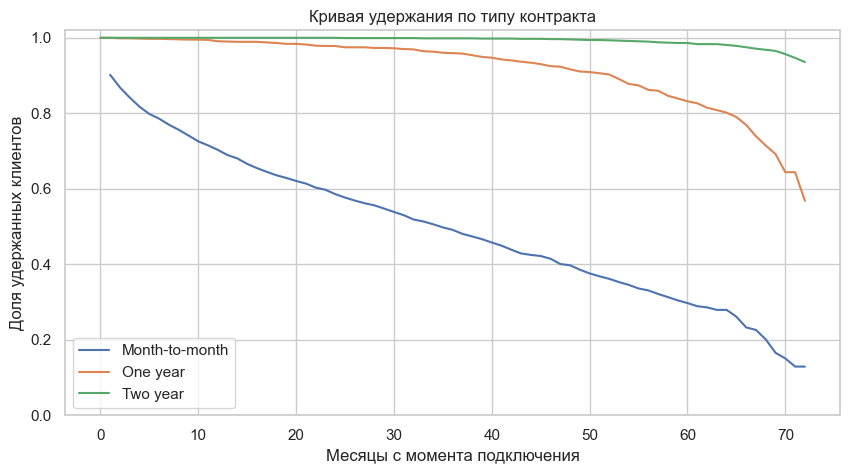

In [7]:
plt.figure(figsize=(10, 5))
for contract_type in df["Contract"].unique():
    km = kaplan_meier(df[df["Contract"] == contract_type])
    plt.plot(km["tenure"], km["survival"], label=contract_type)
plt.xlabel("Месяцы с момента подключения")
plt.ylabel("Доля удержанных клиентов")
plt.title("Кривая удержания по типу контракта")
plt.legend()
plt.ylim(0, 1.02)
plt.show()


**Вывод:** к 12-му месяцу на месячном контракте удержано только 70.3% клиентов, тогда как на годовом — 99.1%, на двухлетнем — 100%. Разрыв огромный и появляется уже в первый год — то есть критическое окно для перевода клиента с месячного на длинный контракт — самые первые месяцы после подключения, а не через год-два.

## 4. Накопленная выручка по клиентам (не LTV в строгом смысле)

`MonthlyCharges × tenure` даёт выручку, **фактически полученную от клиента к текущему моменту**. Для ушедших клиентов это законченная сумма (весь их «путь» с компанией). Для активных — только промежуточный итог: они продолжат платить дальше, и настоящий LTV должен быть выше. Называть эту метрику одинаково «LTV» для обеих групп, как если бы это сопоставимые величины — некорректно, поэтому явно разделяем интерпретацию, а не считаем факт и прогноз одной и той же цифрой.

In [8]:
df["RevenueToDate"] = df["MonthlyCharges"] * df["tenure"]

print("Накопленная выручка (факт), ушедшие клиенты:", round(df[df["Churn"] == 1]["RevenueToDate"].mean(), 2))
print("Накопленная выручка (промежуточный итог), активные клиенты:", round(df[df["Churn"] == 0]["RevenueToDate"].mean(), 2))


Накопленная выручка (факт), ушедшие клиенты: 1531.61
Накопленная выручка (промежуточный итог), активные клиенты: 2549.77


**Осторожная интерпретация:** цифра у активных клиентов оказывается выше, чем у ушедших ($2549.8 против $1531.6) — но это не значит, что активные клиенты «ценнее» в смысле LTV. Это эффект состава групп: среди активных много клиентов с большим `tenure` (то есть тех, кто уже давно платит и продолжит платить дальше), тогда как значительная часть ушедших покидает компанию рано — особенно на месячных контрактах, где, как видно из раздела 3, отток резко идёт с первых месяцев. Прямое сравнение этих двух чисел не говорит ничего о том, кто «прибыльнее» — оно отражает разный состав по времени жизни в компании. Полноценный LTV требует модели ожидаемого оставшегося срока жизни клиента (например, на основе кривой Kaplan-Meier из раздела 3), что выходит за рамки этого проекта.


## 5. Модель предсказания оттока

**Важное исправление по сравнению с первой версией проекта:** в модель необходимо включить именно те признаки, которые раздел 2 определил как наиболее сильно связанные с оттоком — `Contract`, `InternetService`, `OnlineSecurity`, `TechSupport` и другие услуги. Строить модель на демографии (пол, наличие партнёра, наличие городского телефона) и игнорировать тип контракта — значит выбросить из модели самый сильный сигнал, который сам же анализ и нашёл.

In [9]:
categorical_features = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
                         "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                         "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                         "Contract", "PaperlessBilling", "PaymentMethod"]
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

X = pd.get_dummies(df[categorical_features + numeric_features], columns=categorical_features, drop_first=True)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("Признаков после кодирования категорий:", X.shape[1])


Признаков после кодирования категорий: 30


**Про мультиколлинеарность.** `tenure`, `MonthlyCharges` и `TotalCharges` сильно коррелируют между собой (`TotalCharges` — почти произведение первых двух, корреляция с `tenure` = 0.83). Это не мешает модели хорошо предсказывать, но означает, что коэффициент при каждом из этих трёх признаков по отдельности нужно интерпретировать осторожно — модель может «перекладывать» вес между ними почти произвольно.

In [10]:
baseline_accuracy = (y_test == 0).mean()
print(f"Accuracy модели, которая всегда предсказывает «не уйдёт»: {baseline_accuracy:.1%}")


Accuracy модели, которая всегда предсказывает «не уйдёт»: 73.5%


Это и есть причина, по которой одну accuracy использовать нельзя: при дисбалансе классов 73.5%/26.5% даже бесполезная модель, ничего не предсказывающая по существу, покажет высокую accuracy. Сравнивать нужно с этим ориентиром и смотреть на precision/recall/ROC-AUC.

In [11]:
model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}  (ориентир — {baseline_accuracy:.3f})")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1:        {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.3f}")


Accuracy:  0.744  (ориентир — 0.735)
Precision: 0.511
Recall:    0.797
F1:        0.623
ROC-AUC:   0.844


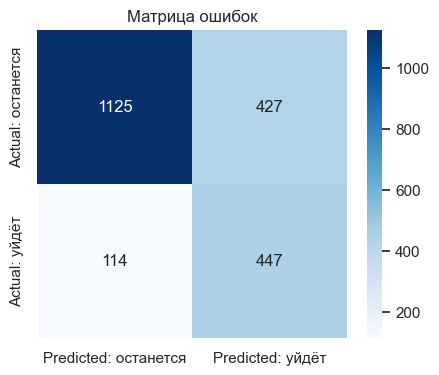

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: останется", "Predicted: уйдёт"],
            yticklabels=["Actual: останется", "Actual: уйдёт"])
plt.title("Матрица ошибок")
plt.show()


**Почему `class_weight="balanced"`, а не дефолтные настройки.** Без него модель показывает accuracy выше (81.0%), но recall всего 56.1% — то есть пропускает почти половину реальных «уходящих» клиентов. С `class_weight="balanced"` recall вырастает до 79.7% ценой падения accuracy до 74.4% и precision до 51.1%.

Для retention-задачи это правильный компромисс: цена пропустить реального уходящего клиента (упущенная выручка, стоимость привлечения нового) обычно намного выше цены лишнего звонка лояльному клиенту (немного менеджерского времени и, возможно, необязательная скидка). Поэтому recall здесь важнее precision, и понижать порог/балансировать классы в пользу recall — осознанное бизнес-решение, а не побочный эффект настроек по умолчанию.

### Какие факторы сильнее всего связаны с оттоком

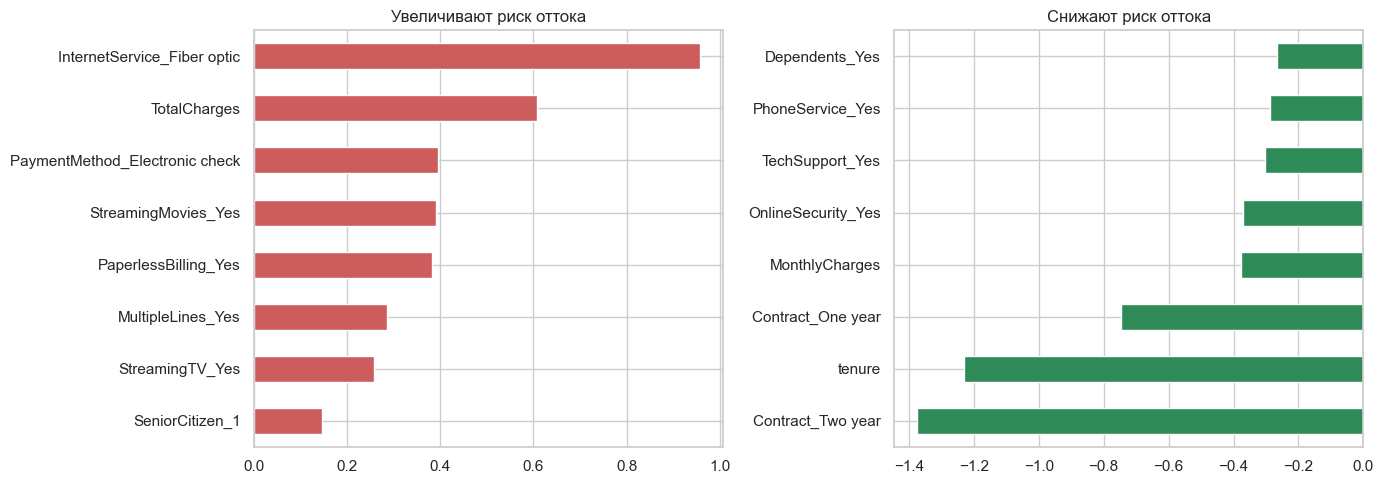

In [13]:
coefficients = pd.Series(model.coef_[0], index=X_train.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
coefficients.tail(8).plot(kind="barh", ax=axes[0], color="indianred")
axes[0].set_title("Увеличивают риск оттока")
coefficients.head(8).plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Снижают риск оттока")
plt.tight_layout()
plt.show()


**Интерпретация (с поправкой на мультиколлинеарность выше):** сильнее всего снижают риск оттока двухлетний и годовой контракт, сам по себе больший `tenure`, наличие `OnlineSecurity` и `TechSupport`. Повышают риск — Fiber optic интернет и оплата через Electronic check. Это согласуется с разделом 2, но модель дополнительно показывает эффект каждого фактора **при контроле за остальными**, а не изолированно.

## 6. Бизнес-рекомендации

1. **Контракт — точка приложения №1.** Разрыв в удержании между месячным и годовым контрактом виден уже в первые 12 месяцев (70.3% против 99.1%) — стимулировать переход на длинные контракты нужно не «когда-нибудь», а в первые месяцы после подключения.
2. **Fiber optic — зона риска, а не просто корреляция.** Связь подтверждена статистически (p ≪ 0.001) и сохраняется в модели при контроле за другими факторами — стоит разобраться, в чём причина (цена, качество, конкуренты), а не только в удержании.
3. **OnlineSecurity/TechSupport как ретеншн-инструмент.** Оба сервиса связаны со снижением оттока даже с учётом остальных факторов — логично предлагать их пробный период клиентам из групп риска.
4. **Модель для точечных кампаний.** С recall ~80% модель отлавливает большинство реальных уходящих клиентов ценой части ложных срабатываний — приемлемо для проактивного контакта retention-команды, но перед продакшен-использованием нужно откалибровать порог под фактическую стоимость звонка и стоимость потери клиента.


## 7. Ограничения

- Данные — единичный срез, а не история по датам: кривая удержания строится на предположении, что клиенты разного `tenure` сопоставимы (нет резких сдвигов в составе клиентской базы или продукте за прошлые годы) — это упрощение.
- Мультиколлинеарность `tenure`/`MonthlyCharges`/`TotalCharges` снижает надёжность интерпретации именно их коэффициентов по отдельности (см. раздел 5).
- `RevenueToDate` — не прогнозный LTV; полноценный LTV требует модели ожидаемого оставшегося срока жизни клиента.
- Логистическая регрессия — базовая модель; для продакшена стоит сравнить с градиентным бустингом и точно откалибровать порог принятия решения под бизнес-стоимость ошибок.

## Итоговое резюме
Отток статистически значимо связан с типом контракта, типом интернета и статусом пенсионера (все p ≪ 0.001). Кривая Kaplan-Meier показывает, что разрыв в удержании между типами контракта формируется уже в первый год. Модель на полном наборе значимых признаков (включая контракт и интернет-услуги, которые в первой версии проекта отсутствовали) даёт ROC-AUC 0.844 и recall 79.7% при балансировке классов — приемлемая основа для точечной retention-кампании.